In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## Linear Models (model 1A): No drift, change in $\sigma$

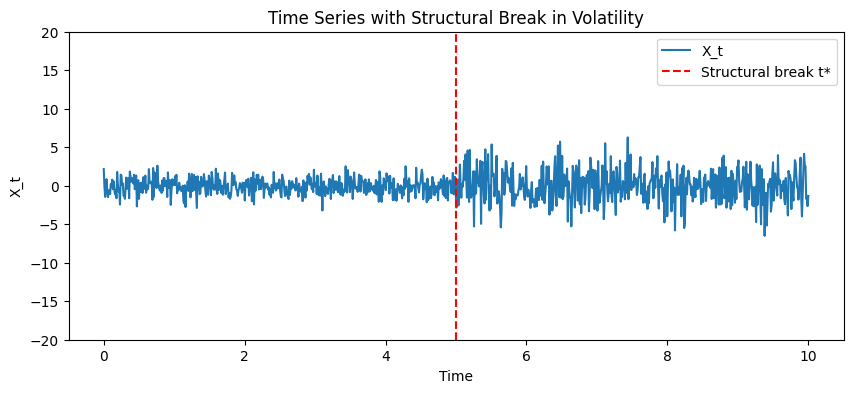

In [65]:
t_star = 5
num_steps = 1000
t = np.linspace(0, 10, num_steps)
Z_t = np.random.normal(0, 1, num_steps)

X_t = np.where(t <= t_star, Z_t, 2 * Z_t)

plt.figure(figsize=(10, 4))
plt.ylim(-20, 20)
plt.plot(t, X_t, label='X_t')
plt.axvline(x=t_star, color='r', linestyle='--', label='Structural break t*')
plt.xlabel('Time')
plt.ylabel('X_t')
plt.title('Time Series with Structural Break in Volatility')
plt.legend()
plt.savefig('C:\\Users\\lisa1\\git\\distribution-shift-detection-with-signature\\figures\\linear_model_1A.png', bbox_inches='tight')
plt.show()

## Linear Models (model 1B):  Drift, no change in $\sigma$

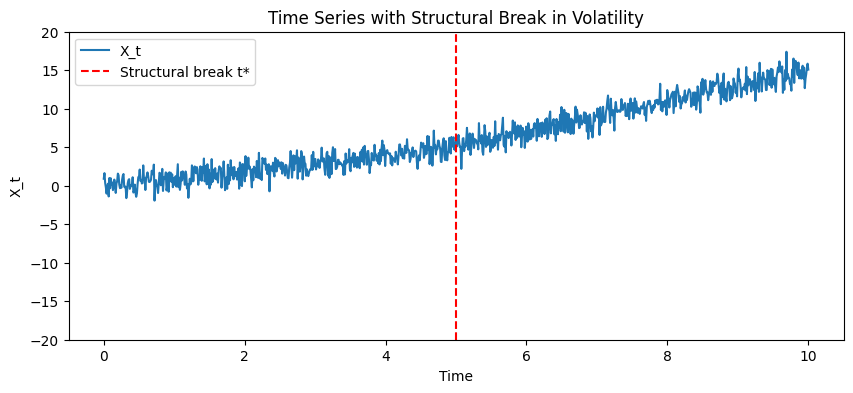

In [66]:
t_star = 5
num_steps = 1000
t = np.linspace(0, 10, num_steps)
Z_t = np.random.normal(0, 1, num_steps)

# adjust the function so that at time t*
X_t = np.where(t <= t_star, t + Z_t, 2 * t - 5 + Z_t)

plt.figure(figsize=(10, 4))
plt.ylim(-20, 20)
plt.plot(t, X_t, label='X_t')
plt.axvline(x=t_star, color='r', linestyle='--', label='Structural break t*')
plt.xlabel('Time')
plt.ylabel('X_t')
plt.title('Time Series with Structural Break in Volatility')
plt.legend()
plt.savefig('C:\\Users\\lisa1\\git\\distribution-shift-detection-with-signature\\figures\\linear_model_1B.png', bbox_inches='tight')   
plt.show()

## Linear Models (model 1C): Flip drift, no change in $\sigma$

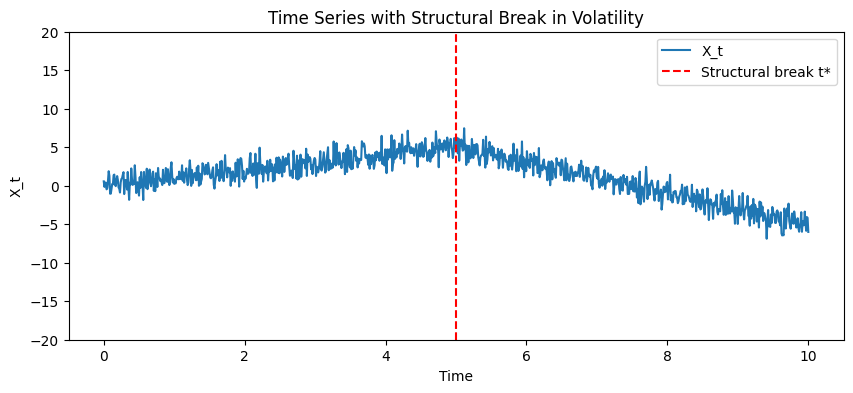

In [67]:
t_star = 5
num_steps = 1000
t = np.linspace(0, 10, num_steps)
Z_t = np.random.normal(0, 1, num_steps)

# adjust the function so that at time t*
X_t = np.where(t <= t_star, t + Z_t, -2 * t + 15 + Z_t)

plt.figure(figsize=(10, 4))
plt.ylim(-20, 20)
plt.plot(t, X_t, label='X_t')
plt.axvline(x=t_star, color='r', linestyle='--', label='Structural break t*')
plt.xlabel('Time')
plt.ylabel('X_t')
plt.title('Time Series with Structural Break in Volatility')
plt.legend()
plt.savefig('C:\\Users\\lisa1\\git\\distribution-shift-detection-with-signature\\figures\\linear_model_1C.png', bbox_inches='tight')
plt.show()

# Autoregressive Model

## AR(1) Models: No drift, No volatility shift, parameter shift, model 2A

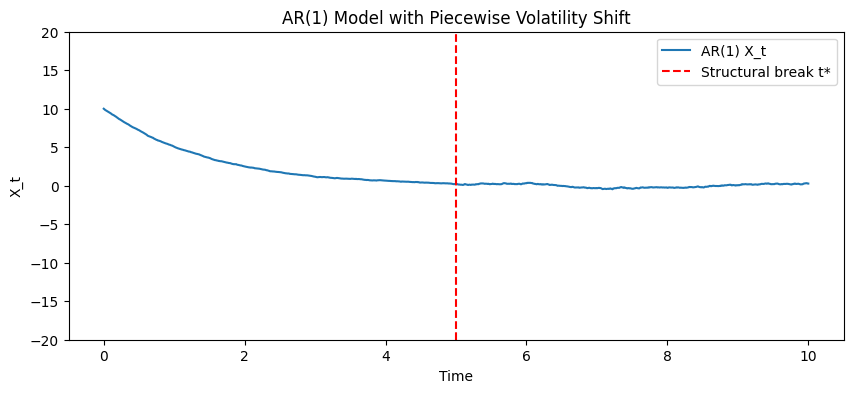

In [4]:
# AR(1) Model: Piecewise volatility shift at t* = 5

def ar1_on_mesh(T=10.0, N=1000, phi=0.5, x0=10.0, t_star=5.0, sigma1=0.1, sigma2=0.2, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    dt = T / N
    t = np.linspace(0.0, T, N+1)          # N steps → N+1 points
    phi_dt = phi ** dt
    c_dt = np.sqrt((1 - phi**(2*dt)) / (1 - phi**2))  # common scaling

    x = np.empty(N+1)
    x[0] = x0
    for k in range(N):
        sigma = sigma1 if t[k+1] <= t_star else sigma2  # switch at t_star
        innov = rng.normal()
        x[k+1] = phi_dt * x[k] + (sigma * c_dt) * innov
    return t, x

t, X_t = ar1_on_mesh(t_star=5.0, sigma1=0.1, sigma2=0.2)
plt.figure(figsize=(10, 4))
plt.ylim(-20, 20)
plt.plot(t, X_t, label='AR(1) X_t')
plt.axvline(x=t_star, color='r', linestyle='--', label='Structural break t*')
plt.xlabel('Time')
plt.ylabel('X_t')
plt.title('AR(1) Model with Piecewise Volatility Shift')
plt.legend()
plt.show()

# Mean Shift

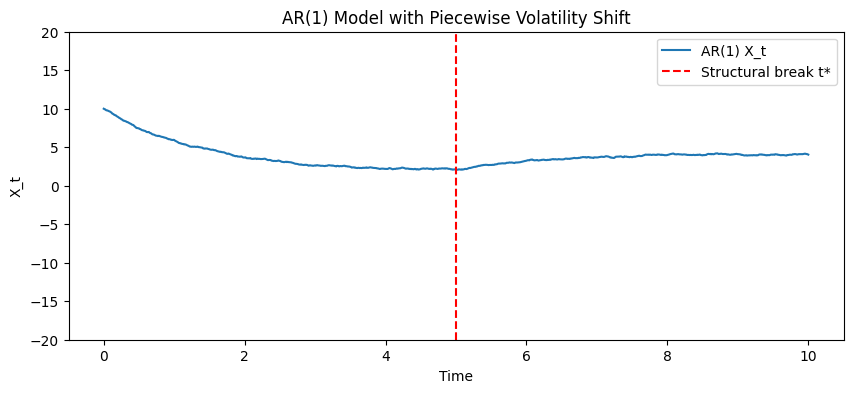

In [8]:
def ar1_on_mesh(T=10.0, N=1000, phi=0.5, x0=10.0, t_star=5.0, sigma=0.15, mean1=0, mean2=0, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    dt = T / N
    t = np.linspace(0.0, T, N+1)          # N steps → N+1 points
    phi_dt = phi ** dt
    c_dt = np.sqrt((1 - phi**(2*dt)) / (1 - phi**2))  # common scaling

    x = np.empty(N+1)
    x[0] = x0
    for k in range(N):
        mean = mean1 if t[k+1] <= t_star else mean2  # switch at t_star
        innov = rng.normal()
        x[k+1] = phi_dt * x[k] + (sigma * c_dt) * innov + mean
    return t, x
t_star = 5.0
t, X_t = ar1_on_mesh(t_star=t_star, sigma=0.2, mean1=0.01, mean2=0.03)
plt.figure(figsize=(10, 4))
plt.ylim(-20, 20)
plt.plot(t, X_t, label='AR(1) X_t')
plt.axvline(x=t_star, color='r', linestyle='--', label='Structural break t*')
plt.xlabel('Time')
plt.ylabel('X_t')
plt.title('AR(1) Model with Piecewise Volatility Shift')
plt.legend()
plt.show()

# Sign flip

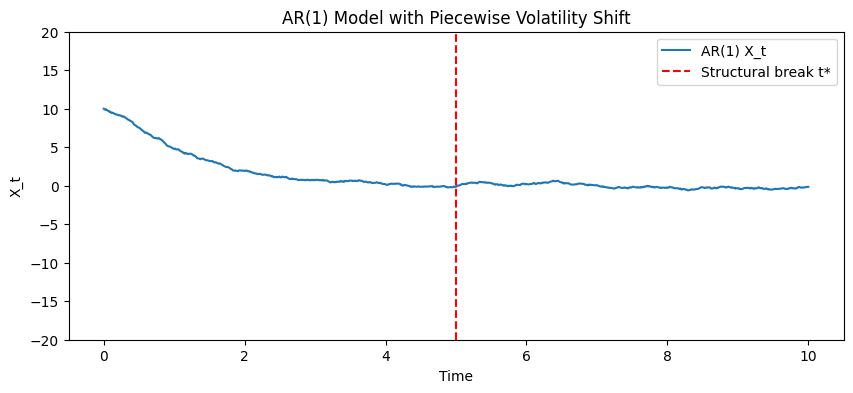

In [ ]:
# AR(1) Model: Piecewise volatility shift at t* = 5

def ar1_on_mesh(T=10.0, N=1000, phi=0.5, x0=10.0, t_star=5.0, sigma1=0.1, sigma2=0.2, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    dt = T / N
    t = np.linspace(0.0, T, N+1)          # N steps → N+1 points
    phi_dt = phi ** dt
    c_dt = np.sqrt((1 - phi**(2*dt)) / (1 - phi**2))  # common scaling

    x = np.empty(N+1)
    x[0] = x0
    for k in range(N):
        sigma = sigma1 if t[k+1] <= t_star else sigma2  # switch at t_star
        innov = rng.normal()
        x[k+1] = phi_dt * x[k] + (sigma * c_dt) * innov
    return t, x

t, X_t = ar1_on_mesh(t_star=5.0, sigma1=0.3, sigma2=-0.3)
plt.figure(figsize=(10, 4))
plt.ylim(-20, 20)
plt.plot(t, X_t, label='AR(1) X_t')
plt.axvline(x=t_star, color='r', linestyle='--', label='Structural break t*')
plt.xlabel('Time')
plt.ylabel('X_t')
plt.title('AR(1) Model with Piecewise Volatility Shift')
plt.legend()
plt.show()